# FIFA World Cup 2026: Yellow Card Analysis

**Name:** Aman Kumar Sah (S398057)
**Email:** s398057@students.cdu.edu.au

**University:** Charles Darwin Univeristy

**Foundations of Data Science**



**Focus of this task:** How many tackels it takes to get a yellow card?

---

## Analytic question

 **Per 10 fouls committed, how many yellow cards were received among outfield players for the FIFA World Cup 2026, and is this rate the same for defenders and midfielders when compared to forwards?**

Most card analysis simply counts the total yellow cards. This analysis has a different goal. This analyzes how many fouls result in a card being made. This is interesting because the referees tend to assess different fouls differently.

$$\text{booking rate} = \frac{\text{yellow cards}}{\text{fouls committed}} \times 10$$

which just means "yellow cards per 10 fouls committed".

When a defender or defensive midfielder fouls, this tends to happen deep in their defensive area, and usually it provides a strategic benefit for the referees to call this foul. Forward fouls tend to occur in the opposing team's defensive area and do not have much impact on the game, so referees tend to call these fouls with only a free kick being given, if at all. It was expected that the booking rate for defenders and midfielders would be greater than for forwards and this analysis is to confirm if that is the case.

**The two things answered here**

1. On average, how many yellow cards per 10 fouls does an outfield player get? (with a confidence interval)
2. Is that rate higher for defenders and midfielders than for forwards? (two-sample t-test)

The question asked is not considered a task. Building a confidence interval and performing a t test are both labeled task 4, as they use the same sample and try to answer the same thing.

Task Skill used

1. Data wrangling
2. Data preparation and sampling
3. Descriptive statistics
4. Inferential statistics: confidence interval (4A) and two-sample t-test (4B) |

## Setup

Import the required libraries and all

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RANDOM_SEED = 42
SAMPLE_SIZE = 200

print('Libraries loaded. Random seed =', RANDOM_SEED)

Libraries loaded. Random seed = 42


---
# Task 1: Data wrangling

The three CSV files are raw exports from the database. To perform any analysis on these files, they must first be combined into a single table.

Steps in this section:

1. Load the three files and check their size.
2. Select only the columns that contain information about the cards and fouls committed by the players during the match. Rename these columns to be easily readable.
3. The `squad` column is to be fixed as it contains the country code in front of the country name.
4. Check for missing values, duplicates and values that do not make sense.
5. Check the player file against the match files to see if they are in agreement with each other.
6. For each player, work out one main position and exclude the goalkeepers.

In [7]:
players = pd.read_csv('/content/players_clean.csv')
matches = pd.read_csv('/content/matches_clean.csv')
team_matches = pd.read_csv('/content/team_matches_clean.csv')

print('players       :', players.shape)
print('matches       :', matches.shape)
print('team_matches  :', team_matches.shape)

players       : (1039, 67)
matches       : (104, 21)
team_matches  : (208, 18)


In [8]:

print('Total columns:', players.shape[1])
print()
print([c for c in players.columns if 'crd' in c or 'card' in c or 'fls' in c or 'fld' in c])

Total columns: 67

['standard_performance_crdy', 'standard_performance_crdr', 'yellow_cards', 'red_cards', 'misc_performance_2crdy', 'misc_performance_fls', 'misc_performance_fld']


In [9]:

keep = {
    'player': 'player',
    'pos': 'pos',
    'squad': 'squad',
    'age': 'age',
    'matches_played': 'matches_played',
    'minutes': 'minutes',
    'yellow_cards': 'yellow_cards',
    'red_cards': 'red_cards',
    'misc_performance_2crdy': 'second_yellows',
    'misc_performance_fls': 'fouls_committed',
    'misc_performance_fld': 'fouls_drawn',
    'misc_performance_tklw': 'tackles_won',
    'misc_performance_int': 'interceptions',
}

df = players[list(keep.keys())].rename(columns=keep)
df.head()

,player,pos,squad,age,matches_played,minutes,yellow_cards,red_cards,second_yellows,fouls_committed,fouls_drawn,tackles_won,interceptions
0,Brenden Aaronson,MF,us USA,25,1,76,0,0,0,2,1,1,0
1,Thelo Aasgaard,MF,no Norway,24,1,90,0,0,0,0,3,1,3
2,Hamza Abdelkarim,FW,eg Egypt,18,4,60,0,0,0,2,0,0,0
3,Hossam Abdelmaguid,DF,eg Egypt,25,2,59,0,0,0,1,0,0,1
4,Mohamed Abdelmonem,DF,eg Egypt,27,2,14,0,0,0,1,0,0,0


In [10]:


df['team'] = df['squad'].str.split(' ', n=1).str[1].str.strip()

print(df[['squad', 'team']].drop_duplicates().head(8).to_string(index=False))
print()
print('Distinct teams:', df['team'].nunique())

          squad         team
         us USA          USA
      no Norway       Norway
       eg Egypt        Egypt
     tn Tunisia      Tunisia
sa Saudi Arabia Saudi Arabia
  uz Uzbekistan   Uzbekistan
       qa Qatar        Qatar
      jo Jordan       Jordan

Distinct teams: 48


In [11]:

print('Missing values per column:')
print(df.isna().sum()[lambda s: s > 0] if df.isna().sum().sum() else '  none')
print()
print('Duplicate player-team rows:', df.duplicated(subset=['player', 'team']).sum())
print()
print('Impossible values check')
print('  negative minutes      :', (df['minutes'] < 0).sum())
print('  negative yellow cards :', (df['yellow_cards'] < 0).sum())
print('  yellow cards > 3      :', (df['yellow_cards'] > 3).sum())
print('  zero minutes played   :', (df['minutes'] == 0).sum())

Missing values per column:
  none

Duplicate player-team rows: 0

Impossible values check
  negative minutes      : 0
  negative yellow cards : 0
  yellow cards > 3      : 0
  zero minutes played   : 0


In [12]:

team_games = team_matches.groupby('team').size().rename('team_matches')
df = df.merge(team_games, left_on='team', right_index=True, how='left')

print('Teams in player file with no match record:', int(df['team_matches'].isna().sum()))
print('Players credited with more matches than their team played:',
      int((df['matches_played'] > df['team_matches']).sum()))


knockout_teams = set(team_matches.loc[team_matches['is_knockout'], 'team'])
df['reached_knockout'] = df['team'].isin(knockout_teams)
print('Teams reaching the knockout stage:', len(knockout_teams))

Teams in player file with no match record: 0
Players credited with more matches than their team played: 0
Teams reaching the knockout stage: 32


In [13]:

df['primary_pos'] = df['pos'].str.split(',').str[0]
print(df['primary_pos'].value_counts(), '\n')



outfield = df[df['primary_pos'] != 'GK'].copy()
print('All players     :', len(df))
print('Outfield players:', len(outfield))

primary_pos
MF    392
DF    349
FW    236
GK     62
Name: count, dtype: int64 

All players     : 1039
Outfield players: 977


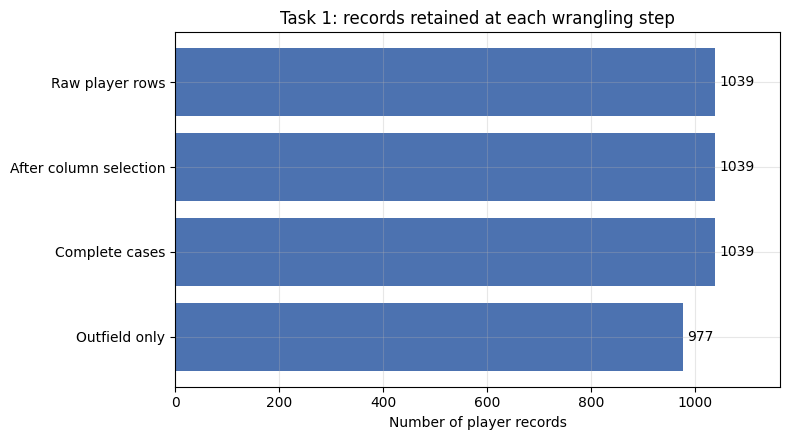

In [14]:

steps = ['Raw player rows', 'After column selection', 'Complete cases', 'Outfield only']
counts = [len(players), len(df), int(df.notna().all(axis=1).sum()), len(outfield)]

fig, ax = plt.subplots()
bars = ax.barh(steps, counts, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('Number of player records')
ax.set_title('Task 1: records retained at each wrangling step')
for b, c in zip(bars, counts):
    ax.text(c + 8, b.get_y() + b.get_height()/2, str(c), va='center')
ax.set_xlim(0, max(counts) * 1.12)
plt.tight_layout()
plt.show()

**Task 1 result.** The data was already in decent shape. There were no missing values, no duplicate players and nobody was recorded as playing more matches than their team actually played. Only the goalkeepers were removed from the data, leaving **977 outfield players** in a clean table with 15 columns.

---
# Task 2: Data preparation and sampling

In this section, we define the variable to be measured, state who constitutes the population of interest and take a sample of that population.

### The variable

$$\text{booking rate}_i = \frac{\text{yellow cards}_i}{\text{fouls committed}_i} \times 10$$

### Population

The population consists of every outfield player who participated in the FIFA World Cup 2026 and committed at least 3 fouls during the tournament.

The 3 foul minimum is necessary for the calculation of the foul rate of each player. The foul rate is calculated as the number of fouls committed by a player divided by the number of cards received by that player. If a player has not committed any fouls, the rate is undefined (as division by zero is undefined). Similarly, if a player has committed only one or two fouls, their foul rate will jump significantly with even a single foul being committed. For instance, if a player commits one foul and receives one yellow card, their foul rate will be 10, showing that they are the dirtiest player in the tournament. So, a minimum of three fouls must be committed by a player before their foul rate can be calculated.

### Sampling

This sample was a stratified random sample of 200 players, split into groups based on their main position on the team (DF, MF, FW) and took the same percentage of players from each group. The use of stratified sampling is due to the fact that the position of the players will be compared in the study and the smallest group of players in the study is the forwards.

In [15]:

population = outfield[outfield['fouls_committed'] >= 3].copy()


population['booking_rate'] = population['yellow_cards'] / population['fouls_committed'] * 10
population['fouls_per90']  = population['fouls_committed'] / (population['minutes'] / 90)
population['cards_per90']  = population['yellow_cards'] / (population['minutes'] / 90)


population['role'] = np.where(population['primary_pos'].isin(['DF', 'MF']),
                              'Defensive/Midfield', 'Forward')

print('Population size N =', len(population))
population[['player', 'team', 'primary_pos', 'minutes',
            'fouls_committed', 'yellow_cards', 'booking_rate']].head()

Population size N = 375


,player,team,primary_pos,minutes,fouls_committed,yellow_cards,booking_rate
5,Ali Abdi,Tunisia,DF,269,4,0,0.0
6,Saud Abdulhamid,Saudi Arabia,DF,269,4,1,2.5
7,Abdulla Abdullaev,Uzbekistan,DF,180,5,0,0.0
16,Ché Adams,Scotland,FW,145,4,0,0.0
18,Tyler Adams,USA,MF,341,5,1,2.0


In [16]:
print('Population composition by position')
print(population['primary_pos'].value_counts().to_frame('N'))
print()
print('Population composition by role')
print(population['role'].value_counts().to_frame('N'))
print()
print('Population mean booking rate: %.4f cards per 10 fouls' % population['booking_rate'].mean())

Population composition by position
               N
primary_pos     
MF           180
DF           127
FW            68

Population composition by role
                      N
role                   
Defensive/Midfield  307
Forward              68

Population mean booking rate: 1.0263 cards per 10 fouls


In [17]:

N = len(population)
frac = SAMPLE_SIZE / N

sample_idx = []
for pos, group in population.groupby('primary_pos'):
    take = int(round(len(group) * frac))
    sample_idx.extend(group.sample(n=take, random_state=RANDOM_SEED).index)

sample = population.loc[sample_idx].copy()

print('Sampling fraction : %.1f%%' % (frac * 100))
print('Sample size n     :', len(sample))
print()
print(sample['primary_pos'].value_counts().to_frame('n'))

Sampling fraction : 53.3%
Sample size n     : 200

              n
primary_pos    
MF           96
DF           68
FW           36


In [18]:

check = pd.DataFrame({
    'Population': [len(population), population['booking_rate'].mean(),
                   population['fouls_committed'].mean(), population['minutes'].mean(),
                   population['age'].mean(),
                   (population['primary_pos'] == 'FW').mean() * 100],
    'Sample':     [len(sample), sample['booking_rate'].mean(),
                   sample['fouls_committed'].mean(), sample['minutes'].mean(),
                   sample['age'].mean(),
                   (sample['primary_pos'] == 'FW').mean() * 100],
}, index=['Size', 'Mean booking rate', 'Mean fouls', 'Mean minutes',
          'Mean age', '% forwards'])

check.round(3)

,Population,Sample
Size,375.000,200.000
Mean booking rate,1.026,1.047
Mean fouls,4.995,4.830
Mean minutes,308.984,299.985
Mean age,27.019,27.065
% forwards,18.133,18.000


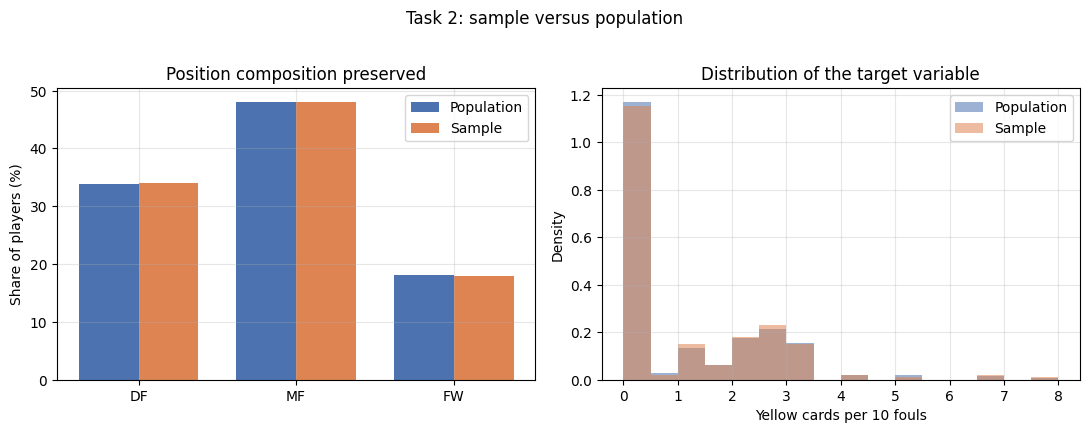

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))


pos_order = ['DF', 'MF', 'FW']
pop_share = population['primary_pos'].value_counts(normalize=True).reindex(pos_order) * 100
smp_share = sample['primary_pos'].value_counts(normalize=True).reindex(pos_order) * 100
x = np.arange(len(pos_order)); w = 0.38
axes[0].bar(x - w/2, pop_share, w, label='Population', color='#4C72B0')
axes[0].bar(x + w/2, smp_share, w, label='Sample', color='#DD8452')
axes[0].set_xticks(x); axes[0].set_xticklabels(pos_order)
axes[0].set_ylabel('Share of players (%)')
axes[0].set_title('Position composition preserved')
axes[0].legend()


bins = np.linspace(0, 8, 17)
axes[1].hist(population['booking_rate'], bins=bins, density=True, alpha=0.55,
             label='Population', color='#4C72B0')
axes[1].hist(sample['booking_rate'], bins=bins, density=True, alpha=0.55,
             label='Sample', color='#DD8452')
axes[1].set_xlabel('Yellow cards per 10 fouls')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of the target variable')
axes[1].legend()

plt.suptitle('Task 2: sample versus population', y=1.02)
plt.tight_layout()
plt.show()

**Task 2 result.** The population came to 375 outfield players (127 DF, 180 MF, 68 FW) and the sample was 200 players (68 DF, 96 MF, 36 FW). The sample mean was 1.047 against the population mean of 1.026. The two plots of the data were similar in both shape and position. So, the sample is representative enough to perform the tests in Task 4.

---
# Task 3: Descriptive statistics

Before running any tests it is worth looking at the sample properly, because the shape of the data decides whether the tests used later are suitable.

In [20]:
br = sample['booking_rate']

desc = pd.Series({
    'n'                  : len(br),
    'Mean'               : br.mean(),
    'Median'             : br.median(),
    'Mode'               : br.mode().iloc[0],
    'Standard deviation' : br.std(ddof=1),
    'Variance'           : br.var(ddof=1),
    'Minimum'            : br.min(),
    'Q1'                 : br.quantile(0.25),
    'Q3'                 : br.quantile(0.75),
    'IQR'                : br.quantile(0.75) - br.quantile(0.25),
    'Maximum'            : br.max(),
    'Range'              : br.max() - br.min(),
    'Skewness'           : br.skew(),
    'Kurtosis'           : br.kurt(),
    'Standard error'     : br.std(ddof=1) / np.sqrt(len(br)),
})

print('Descriptive statistics: yellow cards per 10 fouls (n = %d)' % len(br))
desc.round(4).to_frame('Value')

Descriptive statistics: yellow cards per 10 fouls (n = 200)


,Value
n,200.0000
Mean,1.0473
Median,0.0000
Mode,0.0000
Standard deviation,1.4419
Variance,2.0792
Minimum,0.0000
Q1,0.0000
Q3,2.0000
IQR,2.0000


In [21]:

never_booked = (br == 0).mean() * 100
print('Players in the sample with no yellow card: %.1f%%' % never_booked)
print('Players booked at least once            : %.1f%%' % (100 - never_booked))
print()
print('Distribution of raw yellow card counts in the sample:')
print(sample['yellow_cards'].value_counts().sort_index().to_frame('players'))

Players in the sample with no yellow card: 57.5%
Players booked at least once            : 42.5%

Distribution of raw yellow card counts in the sample:
              players
yellow_cards         
0                 115
1                  73
2                  11
3                   1


In [22]:
by_pos = sample.groupby('primary_pos')['booking_rate'].agg(
    n='count', mean='mean', median='median', sd='std',
    min='min', max='max').reindex(['DF', 'MF', 'FW'])

by_role = sample.groupby('role')['booking_rate'].agg(
    n='count', mean='mean', median='median', sd='std',
    min='min', max='max')

print('By primary position')
print(by_pos.round(3))
print()
print('By role (grouping used for the t-test)')
print(by_role.round(3))

By primary position
              n   mean  median     sd  min    max
primary_pos                                      
DF           68  1.211     0.0  1.500  0.0  7.500
MF           96  1.125     0.0  1.477  0.0  6.667
FW           36  0.533     0.0  1.120  0.0  4.000

By role (grouping used for the t-test)
                      n   mean  median     sd  min  max
role                                                   
Defensive/Midfield  164  1.160     0.0  1.482  0.0  7.5
Forward              36  0.533     0.0  1.120  0.0  4.0


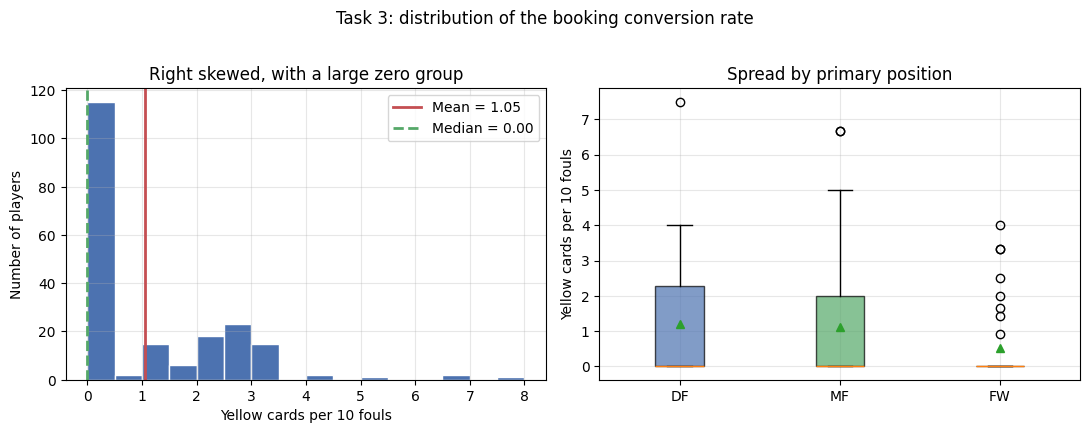

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(br, bins=np.linspace(0, 8, 17), color='#4C72B0', edgecolor='white')
axes[0].axvline(br.mean(), color='#C44E52', lw=2, label='Mean = %.2f' % br.mean())
axes[0].axvline(br.median(), color='#55A868', lw=2, ls='--', label='Median = %.2f' % br.median())
axes[0].set_xlabel('Yellow cards per 10 fouls')
axes[0].set_ylabel('Number of players')
axes[0].set_title('Right skewed, with a large zero group')
axes[0].legend()

data = [sample.loc[sample['primary_pos'] == p, 'booking_rate'] for p in ['DF', 'MF', 'FW']]
bp = axes[1].boxplot(data, patch_artist=True, showmeans=True)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['DF', 'MF', 'FW'])
for patch, colour in zip(bp['boxes'], ['#4C72B0', '#55A868', '#DD8452']):
    patch.set_facecolor(colour); patch.set_alpha(0.7)
axes[1].set_ylabel('Yellow cards per 10 fouls')
axes[1].set_title('Spread by primary position')

plt.suptitle('Task 3: distribution of the booking conversion rate', y=1.02)
plt.tight_layout()
plt.show()

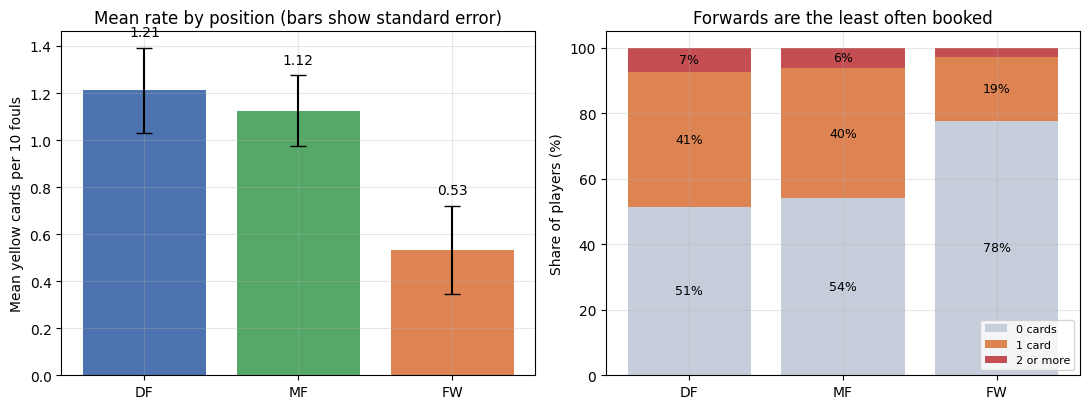

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))


means = by_pos['mean']
errs = by_pos['sd'] / np.sqrt(by_pos['n'])
axes[0].bar(means.index, means.values, yerr=errs.values, capsize=6,
            color=['#4C72B0', '#55A868', '#DD8452'])
axes[0].set_ylabel('Mean yellow cards per 10 fouls')
axes[0].set_title('Mean rate by position (bars show standard error)')
for i, v in enumerate(means.values):
    axes[0].text(i, v + errs.values[i] + 0.05, '%.2f' % v, ha='center')


card_bands = pd.cut(sample['yellow_cards'], bins=[-1, 0, 1, 10],
                    labels=['0 cards', '1 card', '2 or more'])
shares = (pd.crosstab(sample['primary_pos'], card_bands, normalize='index')
            .reindex(['DF', 'MF', 'FW']) * 100)

bottom = np.zeros(len(shares))
for band, colour in zip(shares.columns, ['#C7CEDB', '#DD8452', '#C44E52']):
    axes[1].bar(shares.index, shares[band], bottom=bottom, label=band, color=colour)
    for i, v in enumerate(shares[band]):
        if v > 6:
            axes[1].text(i, bottom[i] + v/2, '%.0f%%' % v, ha='center', va='center', fontsize=9)
    bottom += shares[band].values
axes[1].set_ylabel('Share of players (%)')
axes[1].set_title('Forwards are the least often booked')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

**The third task of this problem** asked for the average number of yellow cards received by each player for every 10 fouls they committed. The answer to this question was 1.05 yellow cards per 10 fouls. Also, the distribution of these numbers is skewed to the right with a skewness of 1.49. The median number of yellow cards received by each player is 0, showing that 57.5% of the players in the sample committed at least three fouls without receiving a yellow card.

Looking at the positions of the players, it can be seen that defenders have an average value of 1.21, midfielders have an average value of 1.12 and forwards have an average value of 0.53. These values show that defenders and midfielders are valued higher than forwards, which is the expected outcome for football players. However, these values only represent the sample of players that were analyzed in this task. Task 4 will reveal the average values of all players in the dataset.

---
# Task 4: Inferential statistics

This section discusses the use of the sample to say something about the whole population of the study, using two different methods.

- 4A. Confidence interval to estimate the average booking rate for the whole population of outfield players.
- 4B. Two-sample t-test to compare defenders and midfielders against forwards.

### About the skewed data

From Task 3, it is apparent that the data is not normally distributed. However, as previously discussed, the t-test does not require the data to be normally distributed; it only requires the sampling distribution of the mean to be normally distributed. With a total of n = 200 observations and 36 in the smallest group, the Central Limit Theorem applies to this situation. Also, the same result can be confirmed with a bootstrap test below.

## Task 4A: Confidence interval for the average booking rate

In [25]:
n_s = len(br)
xbar = br.mean()
s_sd = br.std(ddof=1)
se = s_sd / np.sqrt(n_s)
dfree = n_s - 1
t_crit = stats.t.ppf(0.975, dfree)
moe = t_crit * se

ci_low, ci_high = xbar - moe, xbar + moe

print('Sample mean            : %.4f' % xbar)
print('Sample std deviation   : %.4f' % s_sd)
print('Standard error         : %.4f' % se)
print('Degrees of freedom     : %d' % dfree)
print('Critical t (95%%, 2-tail): %.4f' % t_crit)
print('Margin of error        : %.4f' % moe)
print()
print('95%% CI for the population mean: [%.4f, %.4f]' % (ci_low, ci_high))

Sample mean            : 1.0473
Sample std deviation   : 1.4419
Standard error         : 0.1020
Degrees of freedom     : 199
Critical t (95%, 2-tail): 1.9720
Margin of error        : 0.2011

95% CI for the population mean: [0.8462, 1.2484]


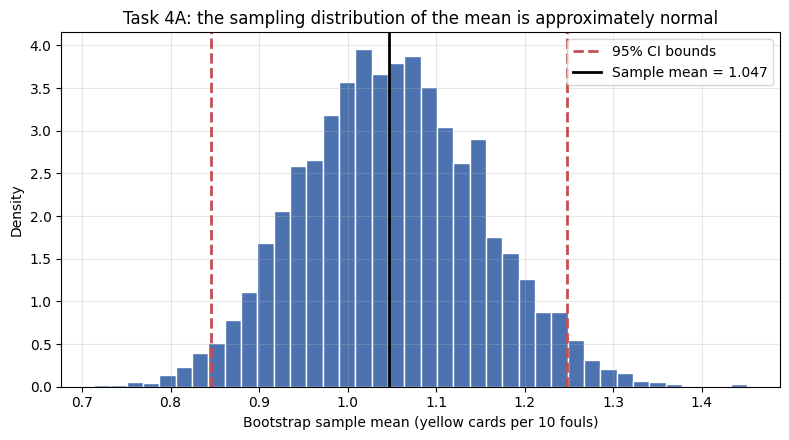

Bootstrap percentile interval: [0.8585, 1.2508]
t based interval             : [0.8462, 1.2484]


In [26]:

rng = np.random.default_rng(RANDOM_SEED)
boot_means = np.array([rng.choice(br.values, size=n_s, replace=True).mean()
                       for _ in range(5000)])

fig, ax = plt.subplots()
ax.hist(boot_means, bins=40, color='#4C72B0', edgecolor='white', density=True)
ax.axvline(ci_low, color='#C44E52', ls='--', lw=2, label='95% CI bounds')
ax.axvline(ci_high, color='#C44E52', ls='--', lw=2)
ax.axvline(xbar, color='black', lw=2, label='Sample mean = %.3f' % xbar)
ax.set_xlabel('Bootstrap sample mean (yellow cards per 10 fouls)')
ax.set_ylabel('Density')
ax.set_title('Task 4A: the sampling distribution of the mean is approximately normal')
ax.legend()
plt.tight_layout()
plt.show()

print('Bootstrap percentile interval: [%.4f, %.4f]' % tuple(np.percentile(boot_means, [2.5, 97.5])))
print('t based interval             : [%.4f, %.4f]' % (ci_low, ci_high))

In [27]:

rows = []
for level in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(level, dfree, loc=xbar, scale=se)
    rows.append({'Confidence level': '%d%%' % (level * 100),
                 'Lower': lo, 'Upper': hi, 'Width': hi - lo})

print(pd.DataFrame(rows).round(4).to_string(index=False))
print()
pop_mean = population['booking_rate'].mean()
print('Actual population mean : %.4f' % pop_mean)
print('Inside the 95%% interval: %s' % (ci_low <= pop_mean <= ci_high))

Confidence level  Lower  Upper  Width
             90% 0.8788 1.2158 0.3370
             95% 0.8462 1.2484 0.4021
             99% 0.7821 1.3125 0.5303

Actual population mean : 1.0263
Inside the 95% interval: True


In [28]:

ci_rows = []
for role, sub in sample.groupby('role'):
    x = sub['booking_rate']
    lo, hi = stats.t.interval(0.95, len(x) - 1,
                              loc=x.mean(), scale=x.std(ddof=1) / np.sqrt(len(x)))
    ci_rows.append({'Group': role, 'n': len(x), 'Mean': x.mean(),
                    'Lower': lo, 'Upper': hi})

ci_table = pd.DataFrame(ci_rows)
ci_table.round(4)

,Group,n,Mean,Lower,Upper
0,Defensive/Midfield,164,1.1603,0.9317,1.3889
1,Forward,36,0.5325,0.1536,0.9115


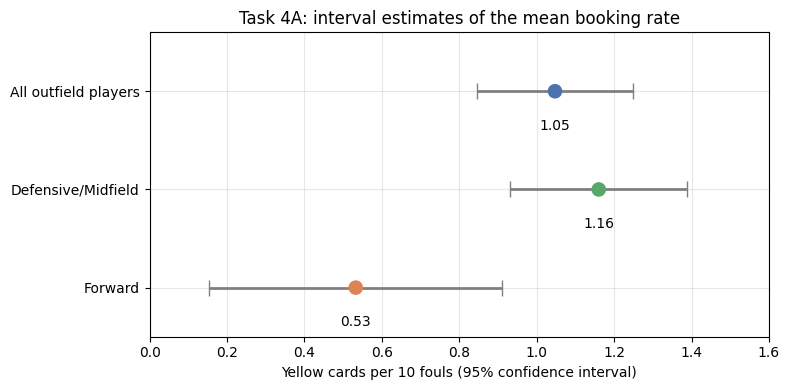

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['All outfield players'] + ci_table['Group'].tolist()
mids = [xbar] + ci_table['Mean'].tolist()
los = [ci_low] + ci_table['Lower'].tolist()
his = [ci_high] + ci_table['Upper'].tolist()
colours = ['#4C72B0', '#55A868', '#DD8452']

y = np.arange(len(labels))
ax.errorbar(mids, y, xerr=[np.array(mids) - np.array(los), np.array(his) - np.array(mids)],
            fmt='none', ecolor='grey', capsize=6, lw=2)
ax.scatter(mids, y, s=90, zorder=3, color=colours)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Yellow cards per 10 fouls (95% confidence interval)')
ax.set_title('Task 4A: interval estimates of the mean booking rate')
ax.set_xlim(0, 1.6)
for i, m in enumerate(mids):
    ax.text(m, i + 0.28, '%.2f' % m, ha='center', va='top')
ax.set_ylim(len(labels) - 0.5, -0.6)
plt.tight_layout()
plt.show()

**Answer to task 4A.** With 95% confidence, the mean booking rate for outfield players in the current World Cup lies in the range of **0.846 and 1.248 bookings for each 10 fouls**. Thus, roughly **one in ten fouls at the tournament ended up being booked with a yellow card**.

There are two ways to confirm that. One is that because we know everything about the population in question, we can find the true population mean and see that it lies within the interval (it equals 1.026). Another one is that our bootstrap confidence interval is very close to the t interval, so the skewness of the distribution does not influence our results.

As one can easily see, the answer to the second part of the question lies in the intervals themselves, because the ranges do not intersect.

## Task 4B: Two sample t-test

Comparison of defenders & midfielders vs forwards.

- $\mu_1$ = mean booking rate of defenders & midfielders
- $\mu_2$ = mean booking rate of forwards

**Hypotheses**

$$H_0: \mu_1 = \mu_2 \qquad \text{(no difference between the positions when considering bookings)}$$
$$H_1: \mu_1 \neq \mu_2 \qquad \text{(there is a difference in the two means)}$$

This test will be two-tailed at a significance level of $\alpha = 0.05$. Although defenders & midfielders were expected to be higher, this test will be two-tailed in order to find a difference in either direction.

In [30]:
group_dm = sample.loc[sample['role'] == 'Defensive/Midfield', 'booking_rate']
group_fw = sample.loc[sample['role'] == 'Forward', 'booking_rate']

print('Defensive/Midfield : n = %3d, mean = %.4f, sd = %.4f' %
      (len(group_dm), group_dm.mean(), group_dm.std(ddof=1)))
print('Forward            : n = %3d, mean = %.4f, sd = %.4f' %
      (len(group_fw), group_fw.mean(), group_fw.std(ddof=1)))
print()
print('Observed difference in means: %.4f' % (group_dm.mean() - group_fw.mean()))

Defensive/Midfield : n = 164, mean = 1.1603, sd = 1.4824
Forward            : n =  36, mean = 0.5325, sd = 1.1201

Observed difference in means: 0.6278


In [31]:

print('1. Independence: each player appears once, in one group only. Satisfied by design.')
print()
print('2. Sample size for the CLT: n1 = %d, n2 = %d, both above 30.' % (len(group_dm), len(group_fw)))
print()
levene = stats.levene(group_dm, group_fw)
print('3. Equality of variances (Levene test): W = %.4f, p = %.4f' % (levene.statistic, levene.pvalue))
print('   p < 0.05, so equal variances cannot be assumed.')
print("   Welch's t-test is therefore used rather than the pooled variance version.")

1. Independence: each player appears once, in one group only. Satisfied by design.

2. Sample size for the CLT: n1 = 164, n2 = 36, both above 30.

3. Equality of variances (Levene test): W = 5.7283, p = 0.0176
   p < 0.05, so equal variances cannot be assumed.
   Welch's t-test is therefore used rather than the pooled variance version.


In [32]:
result = stats.ttest_ind(group_dm, group_fw, equal_var=False)
diff_ci = result.confidence_interval(confidence_level=0.95)


n1, n2 = len(group_dm), len(group_fw)
sp = np.sqrt(((n1 - 1) * group_dm.var(ddof=1) + (n2 - 1) * group_fw.var(ddof=1)) / (n1 + n2 - 2))
cohens_d = (group_dm.mean() - group_fw.mean()) / sp

print("Welch's two-sample t-test")
print('  t statistic        : %.4f' % result.statistic)
print('  degrees of freedom : %.2f' % result.df)
print('  p value (2-tailed) : %.5f' % result.pvalue)
print('  95%% CI of difference: [%.4f, %.4f]' % (diff_ci.low, diff_ci.high))
print("  Cohen's d          : %.3f (small to medium effect)" % cohens_d)

Welch's two-sample t-test
  t statistic        : 2.8580
  degrees of freedom : 65.03
  p value (2-tailed) : 0.00572
  95% CI of difference: [0.1891, 1.0664]
  Cohen's d          : 0.441 (small to medium effect)


In [33]:
alpha = 0.05
print('Significance level alpha = %.2f' % alpha)
print('p value                  = %.5f' % result.pvalue)
print()
if result.pvalue < alpha:
    print('Decision: p < alpha, so REJECT the null hypothesis.')
    print()
    print('Conclusion: there is statistically significant evidence that defenders and')
    print('midfielders receive more yellow cards per 10 fouls than forwards do.')
    print('The mean difference is %.2f cards per 10 fouls, and the 95%% confidence interval'
          % (group_dm.mean() - group_fw.mean()))
    print('for that difference, [%.2f, %.2f], excludes zero.' % (diff_ci.low, diff_ci.high))
else:
    print('Decision: p >= alpha, so FAIL TO REJECT the null hypothesis.')

Significance level alpha = 0.05
p value                  = 0.00572

Decision: p < alpha, so REJECT the null hypothesis.

Conclusion: there is statistically significant evidence that defenders and
midfielders receive more yellow cards per 10 fouls than forwards do.
The mean difference is 0.63 cards per 10 fouls, and the 95% confidence interval
for that difference, [0.19, 1.07], excludes zero.


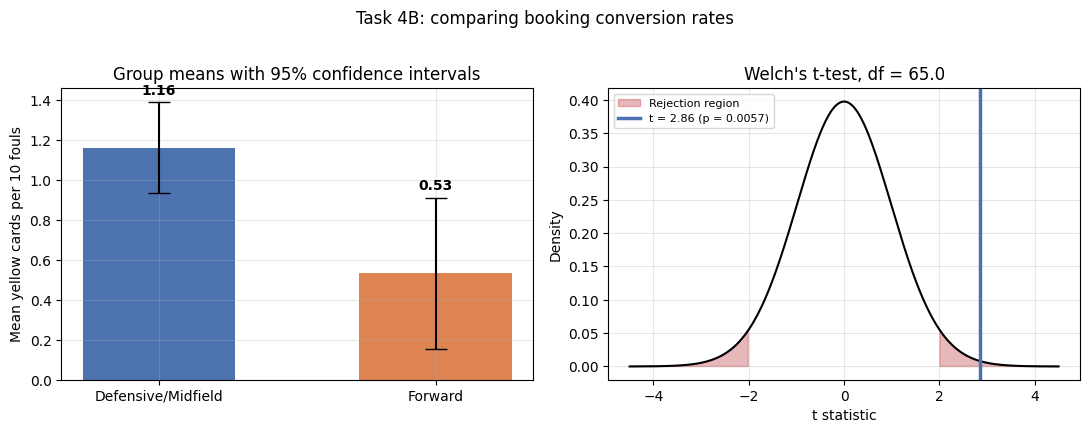

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))


g_names = ['Defensive/Midfield', 'Forward']
g_means = [group_dm.mean(), group_fw.mean()]
g_err = [t_crit * group_dm.std(ddof=1) / np.sqrt(n1),
         stats.t.ppf(0.975, n2 - 1) * group_fw.std(ddof=1) / np.sqrt(n2)]
axes[0].bar(g_names, g_means, yerr=g_err, capsize=8, color=['#4C72B0', '#DD8452'], width=0.55)
axes[0].set_ylabel('Mean yellow cards per 10 fouls')
axes[0].set_title('Group means with 95% confidence intervals')
for i, v in enumerate(g_means):
    axes[0].text(i, v + g_err[i] + 0.04, '%.2f' % v, ha='center', fontweight='bold')


xs = np.linspace(-4.5, 4.5, 500)
axes[1].plot(xs, stats.t.pdf(xs, result.df), color='black', lw=1.5)
crit = stats.t.ppf(0.975, result.df)
axes[1].fill_between(xs, 0, stats.t.pdf(xs, result.df), where=np.abs(xs) >= crit,
                     color='#C44E52', alpha=0.4, label='Rejection region')
axes[1].axvline(result.statistic, color='#4C72B0', lw=2.5,
                label='t = %.2f (p = %.4f)' % (result.statistic, result.pvalue))
axes[1].set_xlabel('t statistic')
axes[1].set_ylabel('Density')
axes[1].set_title("Welch's t-test, df = %.1f" % result.df)
axes[1].legend(fontsize=8)

plt.suptitle('Task 4B: comparing booking conversion rates', y=1.02)
plt.tight_layout()
plt.show()

**Result of Task 4B.** In this case, the test will produce **t = 2.858, df = 65.03, p = 0.0057**. As the p-value is less than 0.05, the null hypothesis is rejected. In general, defenders and midfielders are indeed more likely to be booked for each foul (on average, 1.16 bookings per 10 fouls) compared to forwards (0.53 bookings per 10 fouls). The confidence interval is [0.19, 1.07], so it doesn't contain zero. Additionally, Cohen’s d = 0.44, so it's not only a statistical but also a practical difference.

# Findings

**1. One foul in every ten got a yellow card.**

The sample of 200 players shows an average of 1.05 cards for every 10 fouls. The 95% confidence interval for the population average is between 0.85 and 1.25. This means that 8% to 12% of the fouls committed at this World Cup resulted in a yellow card being shown by the referee.

**2. Most players who fouled were never booked.**

57.5% of the players in the sample committed at three fouls but still did not receive a single yellow card. That’s why the median number of cards is 0 even though the mean is 1.05. The distribution is skewed to the right with a skewness of 1.49. This skew happens because a small number of players collected a lot of cards which raises the average. It’s important to note this because the mean by itself might make it seem like most players get cards but in reality the typical player does not get any.

**3. Where a player fouls seems to matter more than how much he fouls.**

Defenders and midfielders averaged 1.16 cards per 10 fouls while forwards averaged only 0.53. The t-test confirms this difference is statistically significant (t = 2.858 df = 65.03, p = 0.0057) with a to medium effect size (Cohens d = 0.44). In short a forward’s foul was half as likely to result in a yellow card compared to the same number of fouls from a defender or midfielder. This matches Law 12 which says fouls in your defensive area are more likely to stop a clear chance or be judged as reckless. In contrast a foul near the opponent’s penalty area is usually not seen as serious. The stacked bar chart in Task 3 shows the pattern: 78% of forwards ended the tournament with no yellow card compared to 51% of defenders.

**4. Counting cards would have given the wrong impression.**

Defenders and midfielders appear at the top of the yellow card list and they also commit more fouls. So just looking at the number of cards would make it seem like they are being punished more.. When we divide the number of cards by the number of fouls we remove the impact of workload. The difference between positions still exists after this adjustment, which suggests the variation is due to the type of foul not how many fouls a player makes.

**5. Limitations.**

The main limitation is that the data comes from tournament totals not from events. This means we cannot see where on the pitch each foul occurred how serious it was or what minute it happened in. Position is used as a proxy for all of that. Players with than three fouls were excluded to avoid extreme ratios, which means substitutes who played just a few minutes are underrepresented. Forwards are the group in the sample, with only 36 players so their confidence interval is the largest of the three. Also all results use one fixed seed so a different seed would shift the numbers slightly but they should stay within the intervals reported here.